In [1]:
# 0. Kết nối Google Drive trên Google Colab
from google.colab import drive
import os

if not os.path.exists('/content/drive'):
    print("Đang kết nối tới Google Drive...")
    drive.mount('/content/drive')
else:
    print("Google Drive đã được kết nối sẵn!")

Google Drive đã được kết nối sẵn!


In [2]:
# 1. Nạp các thư viện chuẩn cần thiết
import os
import sys
import time
import json
import hashlib
import tracemalloc
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
print("Đã nạp xong thư viện thành công!")

Đã nạp xong thư viện thành công!


In [3]:
# 2. Cấu hình đường dẫn dữ liệu và thư mục lưu trữ kết quả trên Google Drive
LOG_FILE = "/content/drive/MyDrive/accessLog/access.log"
RESULTS_DIR = "/content/drive/MyDrive/accessLog/results"

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Đường dẫn file log: {LOG_FILE}")
print(f"Thư mục lưu kết quả: {RESULTS_DIR}")

Đường dẫn file log: /content/drive/MyDrive/accessLog/access.log
Thư mục lưu kết quả: /content/drive/MyDrive/accessLog/results


In [4]:
# 3. Các hàm băm 64-bit và đếm bit 0 tối ưu hóa phần cứng
def count_trailing_zeros(n):
    """
    Đếm số lượng bit 0 tận cùng của số nguyên n bằng phép toán bitwise O(1).
    """
    if n == 0:
        return 57  # Giới hạn số bit còn lại (64 - 7 bit bucket)
    zeros = 0
    while (n & 1) == 0:
        zeros += 1
        n >>= 1
    return zeros

def hash_64(data_str, seed=42):
    """
    Hàm băm 64-bit đồng nhất: Chỉ băm ĐÚNG 1 LẦN DUY NHẤT cho mỗi phần tử.
    Trả về số nguyên 64-bit không âm.
    """
    salted_input = f"{seed}_{data_str}".encode('utf-8')
    hash_hex = hashlib.md5(salted_input).hexdigest()[:16]
    return int(hash_hex, 16)

print("Đã định nghĩa xong hàm băm 64-bit và đếm bit 0 O(1)!")

Đã định nghĩa xong hàm băm 64-bit và đếm bit 0 O(1)!


In [5]:
# 4. Cài đặt lớp Thuật toán Flajolet-Martin PCSA (PCSA + Median of Means)
class FlajoletMartinPCSA:
    """
    Thuật toán Flajolet-Martin PCSA:
    - Sử dụng kỹ thuật Stochastic Averaging (PCSA - Flajolet & Martin 1985).
    - Chỉ băm 1 lần O(1), tách b bit đầu làm Bucket Index.
    - Kết hợp Median of Means để triệt tiêu ngoại lai.
    """
    def __init__(self, num_buckets=128, num_groups=16, seed=42):
        self.num_buckets = num_buckets
        self.num_groups = num_groups
        self.buckets_per_group = num_buckets // num_groups
        self.seed = seed
        
        # Số bit dùng để phân thùng: 2^b = num_buckets (ví dụ b = 7 cho 128 thùng)
        self.b = (num_buckets - 1).bit_length()
        self.mask = num_buckets - 1  # Mặt nạ bit lấy b bit cuối (0b1111111 cho 128)
        
        # Mảng ghi nhận số bit 0 lớn nhất của từng thùng
        self.max_zeros = [0] * num_buckets
        self.phi = 0.77351  # Hằng số hiệu chỉnh Flajolet-Martin

    def update(self, item):
        """
        Cập nhật phần tử mới với tốc độ siêu nhanh O(1):
        1. Băm ĐÚNG 1 LẦN DUY NHẤT ra số nguyên 64-bit.
        2. Lấy b bit cuối làm chỉ số thùng: bucket = h & mask.
        3. Dịch phải b bit để lấy phần còn lại: rem = h >> b.
        4. Đếm số bit 0 tận cùng và cập nhật thùng tương ứng.
        """
        h = hash_64(item, self.seed)
        bucket = h & self.mask
        rem = h >> self.b
        r = count_trailing_zeros(rem)
        if r > self.max_zeros[bucket]:
            self.max_zeros[bucket] = r

    def estimate(self, method='median_of_means'):
        """
        Ước lượng số lượng phần tử duy nhất F_0:
        - 'median_of_means': Chia 128 thùng thành 16 nhóm x 8 thùng, Mean trong nhóm + Median giữa các nhóm.
        - 'pcsa': Tính trung bình số học trên toàn bộ 128 thùng theo công thức chuẩn PCSA 1985.
        """
        if method == 'median_of_means':
            group_estimates = []
            for g in range(self.num_groups):
                start_idx = g * self.buckets_per_group
                end_idx = start_idx + self.buckets_per_group
                group_zeros = self.max_zeros[start_idx:end_idx]
                
                # Trung bình số mũ trong nhóm
                avg_r = sum(group_zeros) / len(group_zeros)
                # Ước lượng của nhóm (toàn cục tương đương)
                est_g = (self.num_buckets / self.phi) * (2 ** avg_r)
                group_estimates.append(est_g)
            
            # Lấy trung vị (Median) của các nhóm
            group_estimates.sort()
            mid = len(group_estimates) // 2
            if len(group_estimates) % 2 == 0:
                return (group_estimates[mid - 1] + group_estimates[mid]) / 2.0
            else:
                return group_estimates[mid]
        else:
            # Công thức chuẩn PCSA Flajolet-Martin 1985
            avg_r = sum(self.max_zeros) / self.num_buckets
            return (self.num_buckets / self.phi) * (2 ** avg_r)

# Tạo alias để tương thích ngược
FlajoletMartinAdvanced = FlajoletMartinPCSA
print("Đã cài đặt xong lớp FlajoletMartinPCSA (1-Hash PCSA + Median of Means)!")

Đã cài đặt xong lớp FlajoletMartinPCSA (1-Hash PCSA + Median of Means)!


In [6]:
# 5. Hàm đọc luồng dữ liệu (Streaming Generator)
def stream_log_file(file_path):
    if not os.path.exists(file_path):
        print(f"[CẢNH BÁO] Không tìm thấy file: {file_path}")
        return
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if line:
                yield line.split(' ', 1)[0]

In [7]:
# 6. Hàm thực nghiệm Flajolet-Martin PCSA (1-Hash Chia Bit)
def run_fm_pcsa_experiment(log_file_path, sample_step=50000, max_lines=None):
    fm_pcsa = FlajoletMartinPCSA(num_buckets=128, num_groups=16, seed=42)
    stream_counts = []
    estimates_history = []

    # Nạp ground truth từ set_metrics.json trên Google Drive nếu có để đối chiếu
    exact_lookup = {}
    set_file = os.path.join(RESULTS_DIR, 'set_metrics.json')

    if os.path.exists(set_file):
        with open(set_file, 'r', encoding='utf-8') as f:
            set_data = json.load(f)
            for s, u in zip(set_data.get('history_steps', []), set_data.get('history_unique', [])):
                exact_lookup[s] = u

    print("="*75)
    print("BẮT ĐẦU THỰC NGHIỆM FLAJOLET-MARTIN PCSA (1 HASH CHIA BIT)")
    print(f"File: {log_file_path} | Sample step: {sample_step:,} dòng | Cấu hình: 128 thùng (16 nhóm)")
    print("="*75)

    tracemalloc.start()
    start_time = time.time()
    total_processed = 0

    for ip in stream_log_file(log_file_path):
        total_processed += 1
        fm_pcsa.update(ip)

        if total_processed % sample_step == 0:
            est = fm_pcsa.estimate()
            stream_counts.append(total_processed)
            estimates_history.append(est)

            exact_str = f"{exact_lookup[total_processed]:,}" if total_processed in exact_lookup else "N/A"
            speed = total_processed / (time.time() - start_time)
            print(f"Dòng: {total_processed:>10,} | FM Ước lượng: {int(est):>10,} | Thực tế: {exact_str:>10} | Tốc độ: {speed:>10,.0f} dòng/s")

        if max_lines and total_processed >= max_lines:
            break

    elapsed_time = time.time() - start_time
    _, peak_ram = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    final_estimate = fm_pcsa.estimate()
    fm_pcsa_bytes = sys.getsizeof(fm_pcsa) + sys.getsizeof(fm_pcsa.max_zeros) + sum(sys.getsizeof(x) for x in fm_pcsa.max_zeros)

    print("\n" + "="*75)
    print("KẾT QUẢ TỔNG KẾT (FM PCSA - 1 HASH CHIA BIT):")
    print(f"- Tổng số dòng log đã quét:            {total_processed:,}")
    print(f"- Số IP ước lượng cuối cùng:           {int(final_estimate):,}")
    print(f"- Thời gian thực thi:                  {elapsed_time:.2f} giây")
    print(f"- Tốc độ trung bình:                   {total_processed / elapsed_time:,.0f} dòng/giây")
    print(f"- Dung lượng cấu trúc FM PCSA:         {fm_pcsa_bytes:,} Bytes ({fm_pcsa_bytes/1024:.2f} KB)")
    print(f"- Peak RAM hệ thống:                   {peak_ram / (1024*1024):.4f} MB")
    print("="*75)

    # Lưu kết quả trực tiếp vào Google Drive (ghi cả tên mới và tương thích tên cũ)
    out_path = os.path.join(RESULTS_DIR, 'fm_pcsa_metrics.json')
    out_path_compat = os.path.join(RESULTS_DIR, 'fm_advanced_metrics.json')
    results_data = {
        "method": "Flajolet-Martin PCSA (1 Hash Bit-Splitting & Median of Means)",
        "total_processed": total_processed,
        "num_buckets": 128,
        "num_groups": 16,
        "estimate_final": round(final_estimate, 2),
        "elapsed_time": round(elapsed_time, 2),
        "fm_bytes": fm_pcsa_bytes,
        "peak_ram_bytes": peak_ram,
        "history_steps": stream_counts,
        "history_estimates": [round(e, 2) for e in estimates_history]
    }
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(results_data, f, indent=2, ensure_ascii=False)
    with open(out_path_compat, 'w', encoding='utf-8') as f:
        json.dump(results_data, f, indent=2, ensure_ascii=False)
    print(f"-> Đã lưu kết quả thành công tại Google Drive: '{out_path}'!")

    return results_data

In [8]:
# 7. Chạy thực nghiệm
fm_pcsa_results = run_fm_pcsa_experiment(LOG_FILE, sample_step=50000)

BẮT ĐẦU THỰC NGHIỆM FLAJOLET-MARTIN PCSA (1 HASH CHIA BIT)
File: /content/drive/MyDrive/accessLog/access.log | Sample step: 50,000 dòng | Cấu hình: 128 thùng (16 nhóm)
Dòng:     50,000 | FM Ước lượng:      3,291 | Thực tế:      2,179 | Tốc độ:     34,372 dòng/s
Dòng:    100,000 | FM Ước lượng:      6,320 | Thực tế:      3,987 | Tốc độ:     38,351 dòng/s
Dòng:    150,000 | FM Ước lượng:      8,905 | Thực tế:      5,346 | Tốc độ:     31,662 dòng/s
Dòng:    200,000 | FM Ước lượng:     12,071 | Thực tế:      6,510 | Tốc độ:     29,051 dòng/s
Dòng:    250,000 | FM Ước lượng:     13,164 | Thực tế:      7,616 | Tốc độ:     30,464 dòng/s
Dòng:    300,000 | FM Ước lượng:     15,033 | Thực tế:      8,694 | Tốc độ:     32,042 dòng/s
Dòng:    350,000 | FM Ước lượng:     17,200 | Thực tế:      9,685 | Tốc độ:     33,277 dòng/s
Dòng:    400,000 | FM Ước lượng:     17,878 | Thực tế:     10,653 | Tốc độ:     34,283 dòng/s
Dòng:    450,000 | FM Ước lượng:     21,260 | Thực tế:     11,676 | Tốc độ:     

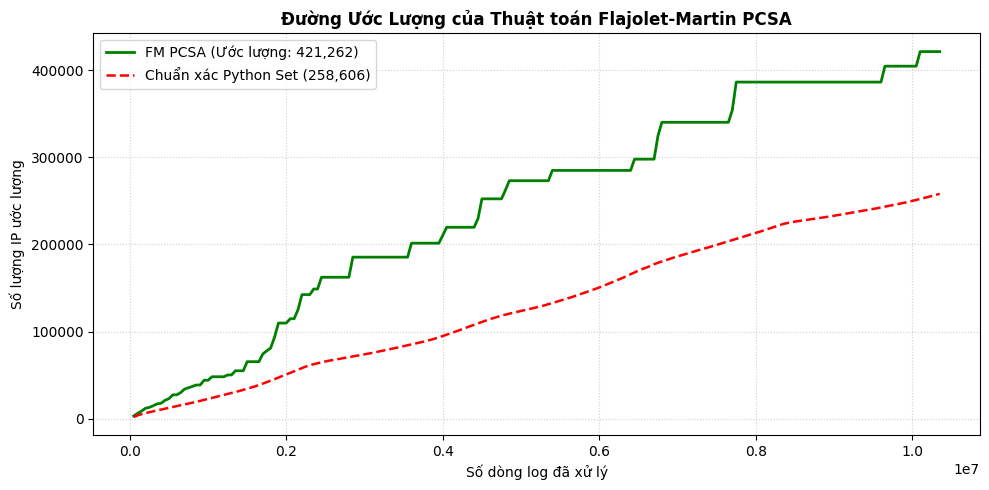

In [9]:
# 8. Trực quan hóa kết quả đọc trực tiếp từ tệp fm_pcsa_metrics.json trên Google Drive
res_file = os.path.join(RESULTS_DIR, 'fm_pcsa_metrics.json')
if not os.path.exists(res_file):
    res_file = os.path.join(RESULTS_DIR, 'fm_advanced_metrics.json')

if os.path.exists(res_file):
    with open(res_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    steps = data['history_steps']
    adv_estimates = data['history_estimates']

    plt.figure(figsize=(10, 5))
    plt.plot(steps, adv_estimates, 'g-', linewidth=2, label=f'FM PCSA (Ước lượng: {int(data["estimate_final"]):,})')
    
    # Vẽ đường đối chiếu chuẩn xác (nếu có dữ liệu Set)
    set_file = os.path.join(RESULTS_DIR, 'set_metrics.json')
    if os.path.exists(set_file):
        with open(set_file, 'r', encoding='utf-8') as f:
            set_data = json.load(f)
            plt.plot(set_data['history_steps'], set_data['history_unique'], 'r--', linewidth=1.8, label=f'Chuẩn xác Python Set ({set_data["exact_final"]:,})')
    
    plt.title('Đường Ước Lượng của Thuật toán Flajolet-Martin PCSA', fontsize=12, fontweight='bold')
    plt.xlabel('Số dòng log đã xử lý')
    plt.ylabel('Số lượng IP ước lượng')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"Chưa tìm thấy tệp '{res_file}'. Vui lòng chạy Cell 7 trước!")